In [3]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from pathlib import Path
matplotlib.rcParams["font.family"] = "DejaVu Sans"

In [6]:
DATA_DIR = Path("/kaggle/input/datasets/kagglercs/data-fusion-strazh")
OUT_DIR = Path("/kaggle/working/eda_plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
"""EDA #1: Обзор данных — кол-во строк, колонок, пропуски."""

# - Список всех файлов данных -
FILES = {
    "pretrain_part_1.parquet",
    "pretrain_part_2.parquet",
    "pretrain_part_3.parquet",
    "train_part_1.parquet",
    "train_part_2.parquet",
    "train_part_3.parquet",
    "train_labels.parquet",
    "pretest.parquet",
    "test.parquet",
}

print("=" * 70)
print("EDA #1: ОБЗОР ДАННЫХ")
print("=" * 70)

# - 1. Анализ пропусков (на train_part_1 как образце) -
for FILENAME in FILES:
    print(f"\n--- Пропуски в файле {FILENAME} ---")
    df_sample = pl.read_parquet(DATA_DIR / FILENAME)
    n_total = df_sample.height
    
    null_stats = []
    for col in df_sample.columns:
        n_null = df_sample[col].null_count()
        pct = 100.0 * n_null / n_total
        null_stats.append((col, n_null, pct))
        if n_null > 0:
            print(f"  {col:40s}: {n_null:>10,} пропусков ({pct:5.1f}%)")
    
    cols_with_nulls = [(c, n, p) for c, n, p in null_stats if n > 0]
    cols_no_nulls = [(c, n, p) for c, n, p in null_stats if n == 0]
    print(f"\n  Колонок с пропусками в файле {FILENAME}:  {len(cols_with_nulls)}")
    print(f"  Колонок без пропусков в файле {FILENAME}: {len(cols_no_nulls)}")

EDA #1: ОБЗОР ДАННЫХ

--- Пропуски в файле pretrain_part_3.parquet ---
  operaton_amt                            : 12,633,803 пропусков ( 41.6%)
  currency_iso_cd                         : 12,085,671 пропусков ( 39.8%)
  mcc_code                                : 19,731,823 пропусков ( 65.0%)
  pos_cd                                  : 20,195,283 пропусков ( 66.5%)
  accept_language                         : 25,398,314 пропусков ( 83.6%)
  browser_language                        : 30,372,137 пропусков (100.0%)
  timezone                                : 25,772,043 пропусков ( 84.9%)
  session_id                              : 30,372,137 пропусков (100.0%)
  operating_system_type                   : 30,372,137 пропусков (100.0%)
  battery                                 : 30,372,137 пропусков (100.0%)
  device_system_version                   : 30,372,137 пропусков (100.0%)
  screen_size                             : 30,372,137 пропусков (100.0%)
  developer_tools                        


Всего размеченных событий: 87,514
Колонки: ['customer_id', 'event_id', 'target']

  RED   (target=1, fraud):          51,438
  YELLOW (target=0, suspicious):     36,076
  Всего размеченных:                87,514
  Доля RED среди размеченных:     58.8%
  train_part_1: 28,618,594 событий
  train_part_2: 28,558,397 событий
  train_part_3: 28,500,849 событий

  Всего событий в трейне:           85,677,840
  GREEN (без метки):                85,590,326
  Доля размеченных:               0.1021%
  Доля RED от всех событий:       0.0600%


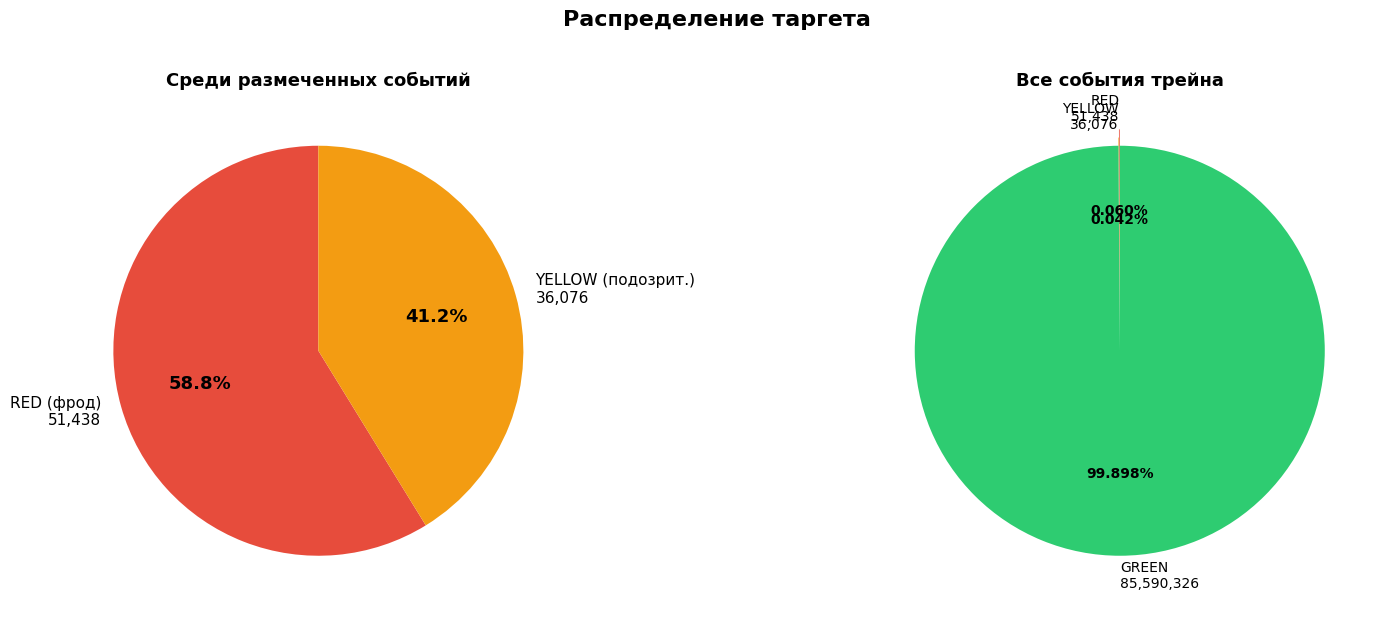


График сохранён: /kaggle/working/eda_plots/02_target_distribution.png


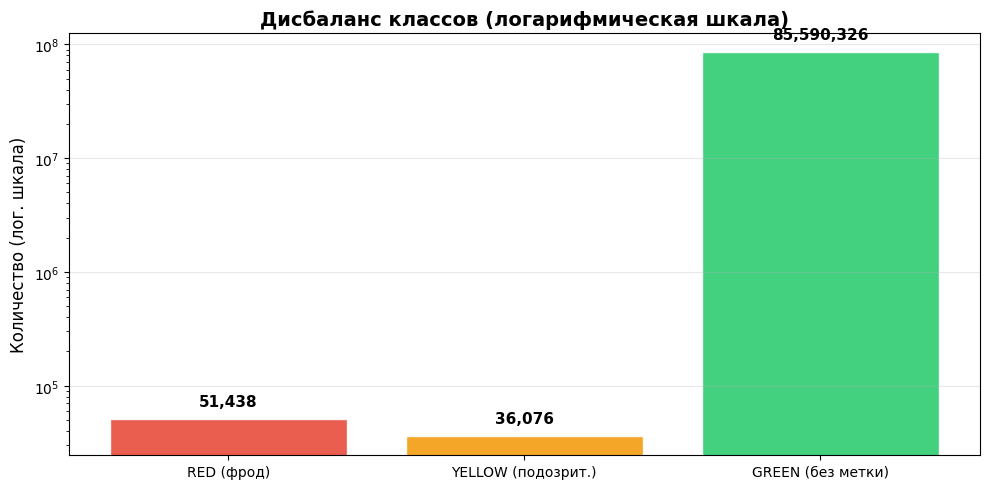

График сохранён: /kaggle/working/eda_plots/02_class_imbalance_log.png


In [9]:
"""EDA #2: Распределение таргета."""

# - 1. Загрузка меток -
labels = pl.read_parquet(DATA_DIR / "train_labels.parquet")
print(f"\nВсего размеченных событий: {labels.height:,}")
print(f"Колонки: {labels.columns}")

# - 2. Подсчёт RED и YELLOW -
red_count = labels.filter(pl.col("target") == 1).height
yellow_count = labels.filter(pl.col("target") == 0).height
print(f"\n  RED   (target=1, fraud):        {red_count:>8,}")
print(f"  YELLOW (target=0, suspicious):   {yellow_count:>8,}")
print(f"  Всего размеченных:              {labels.height:>8,}")
print(f"  Доля RED среди размеченных:     {100*red_count/labels.height:.1f}%")

# - 3. Подсчёт GREEN (неразмеченных) -
total_train_events = 0
for i in [1, 2, 3]:
    n = pl.scan_parquet(DATA_DIR / f"train_part_{i}.parquet").select(pl.len()).collect().item()
    total_train_events += n
    print(f"  train_part_{i}: {n:,} событий")

green_count = total_train_events - labels.height
print(f"\n  Всего событий в трейне:         {total_train_events:>12,}")
print(f"  GREEN (без метки):              {green_count:>12,}")
print(f"  Доля размеченных:               {100*labels.height/total_train_events:.4f}%")
print(f"  Доля RED от всех событий:       {100*red_count/total_train_events:.4f}%")

# - 4. Визуализация (RED vs YELLOW) -
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Среди размеченных
ax = axes[0]
sizes = [red_count, yellow_count]
labels_pie = [f"RED (фрод)\n{red_count:,}", f"YELLOW (подозрит.)\n{yellow_count:,}"]
colors = ["#e74c3c", "#f39c12"]
wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors,
                                   autopct="%1.1f%%", startangle=90,
                                   textprops={"fontsize": 11})
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(13)
ax.set_title("Среди размеченных событий", fontsize=13, fontweight="bold")

# Все события
ax = axes[1]
sizes_all = [red_count, yellow_count, green_count]
labels_all = [f"RED\n{red_count:,}", f"YELLOW\n{yellow_count:,}", f"GREEN\n{green_count:,}"]
colors_all = ["#e74c3c", "#f39c12", "#2ecc71"]
explode = (0.08, 0.04, 0)
wedges, texts, autotexts = ax.pie(sizes_all, labels=labels_all, colors=colors_all,
                                   autopct="%1.3f%%", startangle=90, explode=explode,
                                   textprops={"fontsize": 10})
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title("Все события трейна", fontsize=13, fontweight="bold")

plt.suptitle("Распределение таргета", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nГрафик сохранён: {OUT_DIR / '02_target_distribution.png'}")

# - 5. Log-шкала -
fig, ax = plt.subplots(figsize=(10, 5))
categories = ["RED (фрод)", "YELLOW (подозрит.)", "GREEN (без метки)"]
counts = [red_count, yellow_count, green_count]
colors_bar = ["#e74c3c", "#f39c12", "#2ecc71"]
bars = ax.bar(categories, counts, color=colors_bar, edgecolor="white", alpha=0.9)
ax.set_yscale("log")
ax.set_ylabel("Количество (лог. шкала)", fontsize=12)
ax.set_title("Дисбаланс классов (логарифмическая шкала)", fontsize=14, fontweight="bold")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            f"{cnt:,}", ha="center", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_class_imbalance_log.png", dpi=150)
plt.show()
print(f"График сохранён: {OUT_DIR / '02_class_imbalance_log.png'}")


Загрузка данных...
  train_part_1...
  train_part_2...
  train_part_3...

  RED:      30,317 транзакций
  YELLOW:   19,864 транзакций
  GREEN:   459,181 транзакций (1% сэмпл)

--- Статистики сумм (abs) ---

  RED:
    Среднее:   7,070,437.2
    Медиана:     396,640.0
    Мин:               0.0
    Макс:     1,489,800,763.0
    95й перцентиль:      31,644,860.0
    99й перцентиль:      99,790,000.0

  YELLOW:
    Среднее:  23,212,211.4
    Медиана:   1,044,771.5
    Мин:               0.0
    Макс:     37,252,983,372.0
    95й перцентиль:      89,872,650.0
    99й перцентиль:      219,797,793.3

  GREEN:
    Среднее:   2,386,141.4
    Медиана:      70,651.0
    Мин:               0.0
    Макс:     67,745,758,465.0
    95й перцентиль:       3,615,120.0
    99й перцентиль:      29,910,000.0


/tmp/ipykernel_55/1532736911.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=["RED", "YELLOW", "GREEN"],


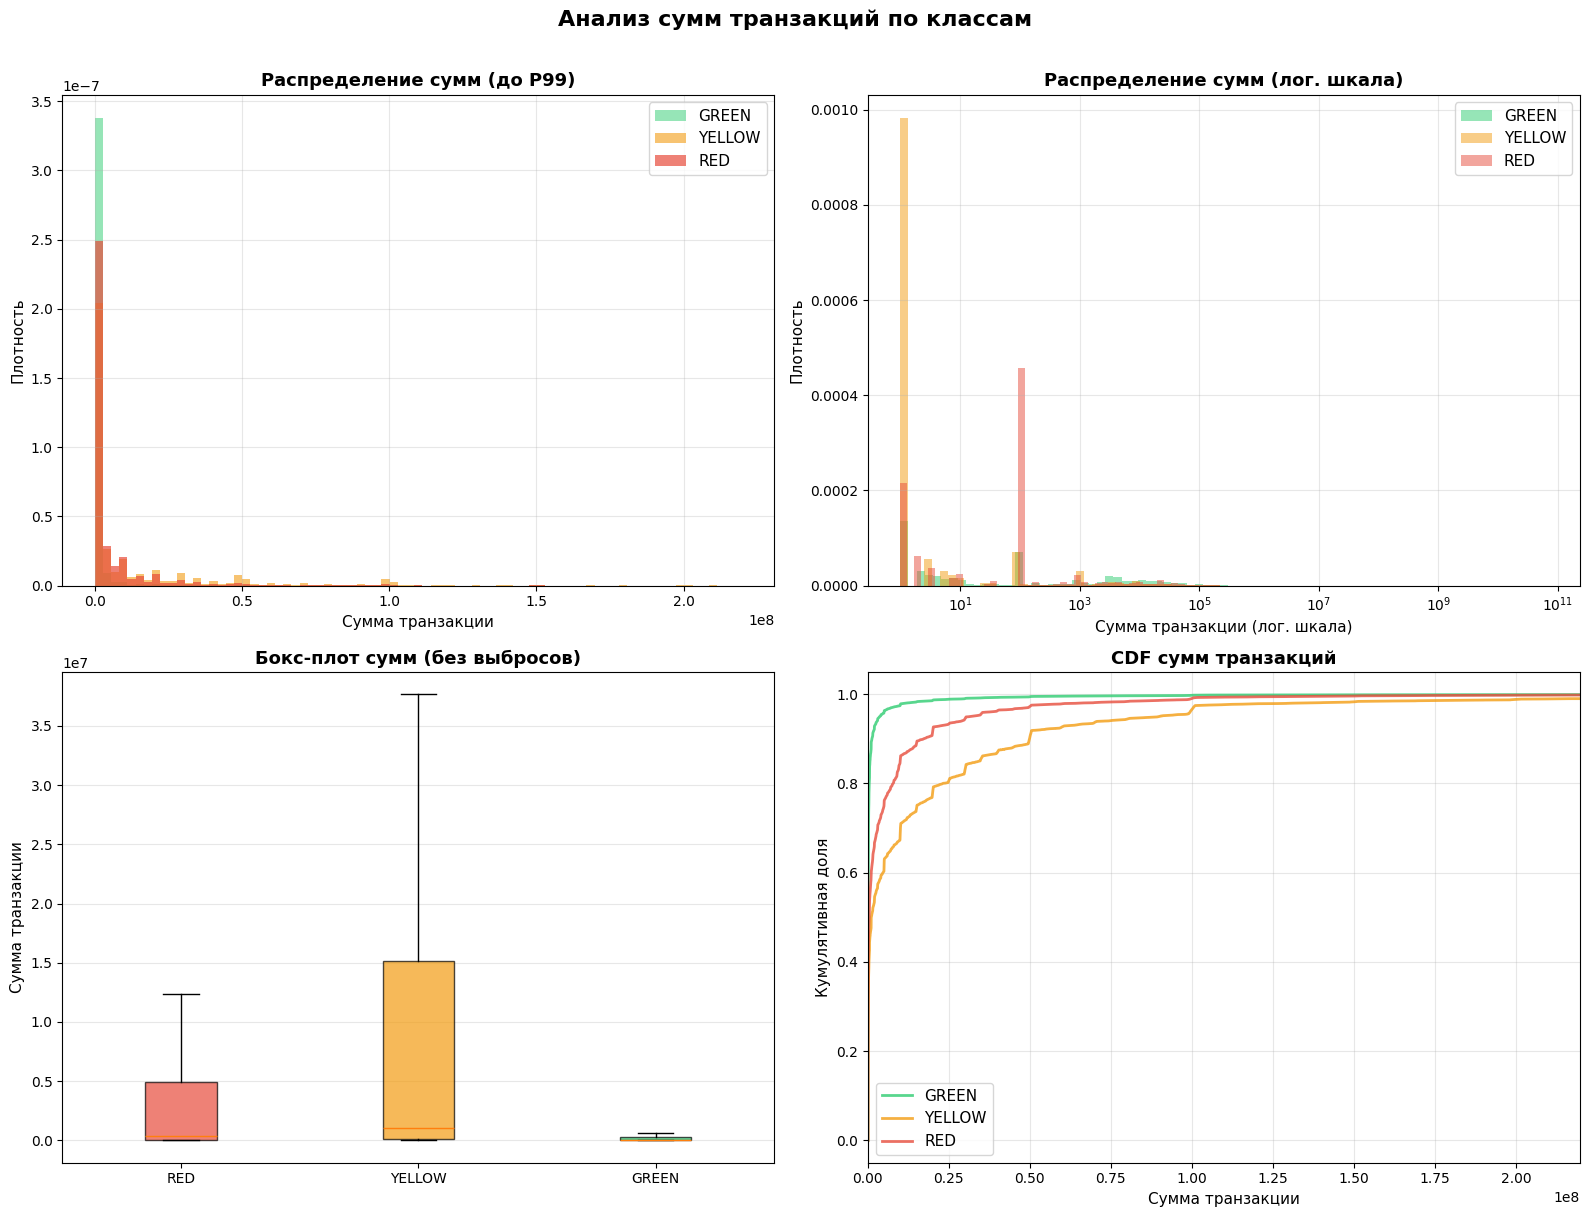


График сохранён: /kaggle/working/eda_plots/03_amount_distributions.png


In [10]:
"""EDA #3: Распределение сумм транзакций по классам (фрод / подозрительные / нормальные)."""

# - 1. Загрузка меток -
labels = pl.read_parquet(DATA_DIR / "train_labels.parquet")
labeled_ids = set(labels["event_id"].to_list())
target_map = dict(zip(labels["event_id"].to_list(), labels["target"].to_list()))

# - 2. Загрузка сумм из train (сэмпл для GREEN) -
print("\nЗагрузка данных...")
all_amts = {"RED": [], "YELLOW": [], "GREEN": []}

for i in [1, 2, 3]:
    print(f"  train_part_{i}...")
    df = pl.read_parquet(DATA_DIR / f"train_part_{i}.parquet",
                         columns=["event_id", "operaton_amt"])
    df = df.with_columns(pl.col("operaton_amt").cast(pl.Float64).alias("amt"))

    # RED и YELLOW — все
    for row in df.filter(pl.col("event_id").is_in(list(labeled_ids))).iter_rows(named=True):
        t = target_map.get(row["event_id"])
        amt = row["amt"]
        if amt is None:
            continue
        if t == 1:
            all_amts["RED"].append(abs(amt))
        elif t == 0:
            all_amts["YELLOW"].append(abs(amt))

    # GREEN — случайный сэмпл - 1%
    green_df = df.filter(~pl.col("event_id").is_in(list(labeled_ids)))
    sample_n = max(1, green_df.height // 100)
    green_sample = green_df.sample(n=sample_n, seed=42)
    for amt in green_sample["amt"].to_list():
        if amt is not None:
            all_amts["GREEN"].append(abs(amt))

    del df, green_df, green_sample

print(f"\n  RED:    {len(all_amts['RED']):>8,} транзакций")
print(f"  YELLOW: {len(all_amts['YELLOW']):>8,} транзакций")
print(f"  GREEN:  {len(all_amts['GREEN']):>8,} транзакций (1% сэмпл)")

# - 3. Статистики -
print("\n--- Статистики сумм (abs) ---")
for label, amts in all_amts.items():
    arr = np.array(amts)
    print(f"\n  {label}:")
    print(f"    Среднее:  {np.mean(arr):>12,.1f}")
    print(f"    Медиана:  {np.median(arr):>12,.1f}")
    print(f"    Мин:      {np.min(arr):>12,.1f}")
    print(f"    Макс:     {np.max(arr):>12,.1f}")
    print(f"    95й перцентиль:      {np.percentile(arr, 95):>12,.1f}")
    print(f"    99й перцентиль:      {np.percentile(arr, 99):>12,.1f}")

# - 4. Гистограммы распределений -
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
p99 = max(np.percentile(all_amts["RED"], 99),
          np.percentile(all_amts["YELLOW"], 99),
          np.percentile(all_amts["GREEN"], 99))
bins = np.linspace(0, p99, 80)
ax.hist(all_amts["GREEN"], bins=bins, alpha=0.5, color="#2ecc71", label="GREEN", density=True)
ax.hist(all_amts["YELLOW"], bins=bins, alpha=0.6, color="#f39c12", label="YELLOW", density=True)
ax.hist(all_amts["RED"], bins=bins, alpha=0.7, color="#e74c3c", label="RED", density=True)
ax.set_xlabel("Сумма транзакции", fontsize=11)
ax.set_ylabel("Плотность", fontsize=11)
ax.set_title("Распределение сумм (до P99)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Log-масштаб X
ax = axes[0, 1]
for label, color, amts in [("GREEN", "#2ecc71", all_amts["GREEN"]),
                             ("YELLOW", "#f39c12", all_amts["YELLOW"]),
                             ("RED", "#e74c3c", all_amts["RED"])]:
    arr = np.array(amts)
    arr = arr[arr > 0]  # для лога
    log_bins = np.logspace(np.log10(max(1, arr.min())), np.log10(arr.max()), 80)
    ax.hist(arr, bins=log_bins, alpha=0.5, color=color, label=label, density=True)
ax.set_xscale("log")
ax.set_xlabel("Сумма транзакции (лог. шкала)", fontsize=11)
ax.set_ylabel("Плотность", fontsize=11)
ax.set_title("Распределение сумм (лог. шкала)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Box-plot
ax = axes[1, 0]
data_box = [np.clip(all_amts["RED"], 0, p99),
            np.clip(all_amts["YELLOW"], 0, p99),
            np.clip(all_amts["GREEN"], 0, p99)]
bp = ax.boxplot(data_box, labels=["RED", "YELLOW", "GREEN"],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], ["#e74c3c", "#f39c12", "#2ecc71"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Сумма транзакции", fontsize=11)
ax.set_title("Бокс-плот сумм (без выбросов)", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3, axis="y")

# CDF (cumulative)
ax = axes[1, 1]
for label, color, amts in [("GREEN", "#2ecc71", all_amts["GREEN"]),
                             ("YELLOW", "#f39c12", all_amts["YELLOW"]),
                             ("RED", "#e74c3c", all_amts["RED"])]:
    arr = np.sort(amts)
    cdf = np.arange(1, len(arr)+1) / len(arr)
    ax.plot(arr, cdf, color=color, label=label, linewidth=2, alpha=0.8)
ax.set_xlim(0, p99)
ax.set_xlabel("Сумма транзакции", fontsize=11)
ax.set_ylabel("Кумулятивная доля", fontsize=11)
ax.set_title("CDF сумм транзакций", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle("Анализ сумм транзакций по классам", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_amount_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nГрафик сохранён: {OUT_DIR / '03_amount_distributions.png'}")

RED событий: 51,438, YELLOW: 36,076

Сбор MCC-кодов...
  train_part_1...
  train_part_2...
  train_part_3...

--- Топ-20 MCC по количеству RED (фрод) ---
       MCC       RED    YELLOW       Всего    RED rate
        -1    35,377    28,725  61,050,347     0.0579%
        10     5,671     2,896   2,714,292     0.2089%
        16     3,687        64     508,617     0.7249%
         4     2,283     2,062  11,488,996     0.0199%
        19     1,001       213     979,081     0.1022%
         3       957        44     245,850     0.3893%
        15       542       513   2,363,713     0.0229%
        17       462       403   1,925,036     0.0240%
        18       450        85     270,807     0.1662%
        14       347       149     637,817     0.0544%
         9       116       230   1,080,827     0.0107%
         1       102       234     967,278     0.0105%
        13        95        32      76,681     0.1239%
         7        95       185     751,706     0.0126%
         2        88 

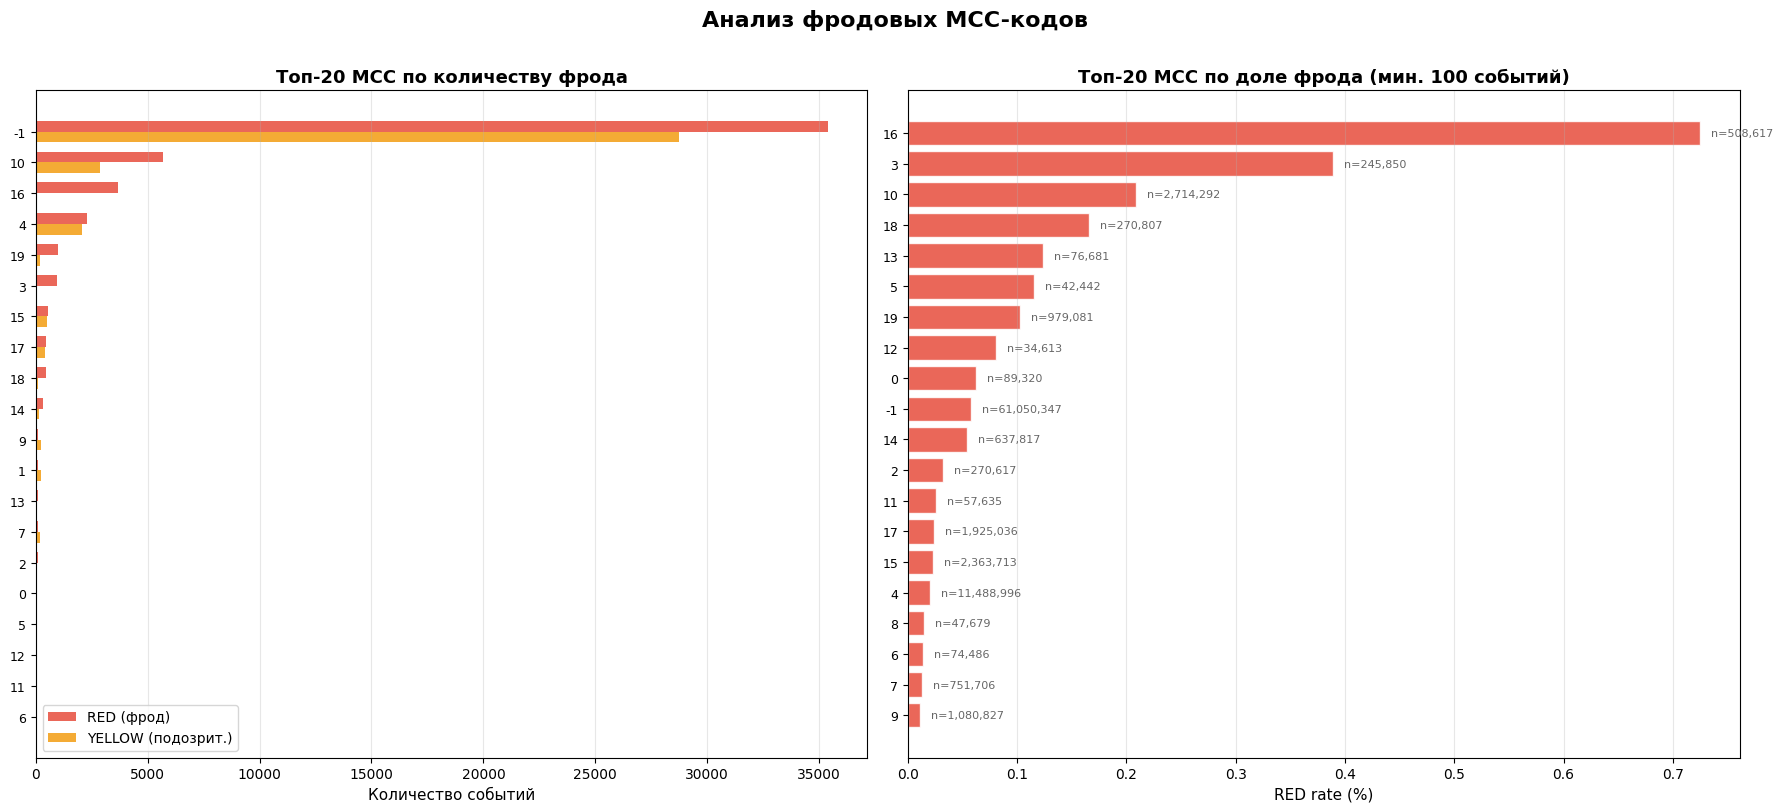


График сохранён: /kaggle/working/eda_plots/04_fraudulent_mcc.png

--- Концентрация фрода по MCC ---
  Топ- 1 MCC: 35,377 RED (68.8% от всех RED)
  Топ- 3 MCC: 44,735 RED (87.0% от всех RED)
  Топ- 5 MCC: 48,019 RED (93.4% от всех RED)
  Топ-10 MCC: 50,777 RED (98.7% от всех RED)
  Топ-20 MCC: 51,431 RED (100.0% от всех RED)


In [11]:
"""EDA #4: Преобладающие фродовые MCC-коды."""

# - 1. Загрузка меток -
labels = pl.read_parquet(DATA_DIR / "train_labels.parquet")
red_ids = set(labels.filter(pl.col("target") == 1)["event_id"].to_list())
yellow_ids = set(labels.filter(pl.col("target") == 0)["event_id"].to_list())
labeled_ids = red_ids | yellow_ids
print(f"RED событий: {len(red_ids):,}, YELLOW: {len(yellow_ids):,}")

# - 2. Сбор MCC для каждого класса -
print("\nСбор MCC-кодов...")
mcc_red = []
mcc_yellow = []
mcc_all_counts = {}

for i in [1, 2, 3]:
    print(f"  train_part_{i}...")
    df = pl.read_parquet(DATA_DIR / f"train_part_{i}.parquet",
                         columns=["event_id", "mcc_code"])
    df = df.with_columns(pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc"))

    # Подсчёт MCC по всем событиям
    for mcc, cnt in df.group_by("mcc").len().iter_rows():
        mcc_all_counts[mcc] = mcc_all_counts.get(mcc, 0) + cnt

    # MCC для размеченных
    labeled_df = df.filter(pl.col("event_id").is_in(list(labeled_ids)))
    for row in labeled_df.iter_rows(named=True):
        eid = row["event_id"]
        mcc = row["mcc"]
        if eid in red_ids:
            mcc_red.append(mcc)
        elif eid in yellow_ids:
            mcc_yellow.append(mcc)

    del df, labeled_df

# - 3. Подсчёт -
from collections import Counter
red_ctr = Counter(mcc_red)
yellow_ctr = Counter(mcc_yellow)

# Топ-20 MCC по кол-ву RED
top_red_mcc = red_ctr.most_common(20)
print("\n--- Топ-20 MCC по количеству RED (фрод) ---")
print(f"  {'MCC':>8s}  {'RED':>8s}  {'YELLOW':>8s}  {'Всего':>10s}  {'RED rate':>10s}")
for mcc, cnt in top_red_mcc:
    y_cnt = yellow_ctr.get(mcc, 0)
    total = mcc_all_counts.get(mcc, 1)
    rate = 100.0 * cnt / total
    print(f"  {mcc:>8d}  {cnt:>8,}  {y_cnt:>8,}  {total:>10,}  {rate:>9.4f}%")

# - 4. Топ-20 MCC по RED rate (мин. 100 событий) -
mcc_rates = []
for mcc in set(list(red_ctr.keys()) + list(yellow_ctr.keys())):
    total = mcc_all_counts.get(mcc, 0)
    if total < 100:
        continue
    r = red_ctr.get(mcc, 0)
    y = yellow_ctr.get(mcc, 0)
    mcc_rates.append((mcc, r, y, total, 100.0 * r / total))

mcc_rates.sort(key=lambda x: x[4], reverse=True)

print("\n--- Топ-20 MCC по RED rate (мин. 100 событий) ---")
print(f"  {'MCC':>8s}  {'RED':>8s}  {'YELLOW':>8s}  {'Всего':>10s}  {'RED rate':>10s}")
for mcc, r, y, total, rate in mcc_rates[:20]:
    print(f"  {mcc:>8d}  {r:>8,}  {y:>8,}  {total:>10,}  {rate:>9.4f}%")

# - 5. Визуализация: Топ-20 MCC по количеству RED -
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 5a. По количеству RED
ax = axes[0]
mccs = [str(m) for m, _ in top_red_mcc]
reds = [c for _, c in top_red_mcc]
yellows = [yellow_ctr.get(m, 0) for m, _ in top_red_mcc]
x = np.arange(len(mccs))
w = 0.35
ax.barh(x - w/2, reds, w, color="#e74c3c", alpha=0.85, label="RED (фрод)")
ax.barh(x + w/2, yellows, w, color="#f39c12", alpha=0.85, label="YELLOW (подозрит.)")
ax.set_yticks(x)
ax.set_yticklabels(mccs, fontsize=9)
ax.set_xlabel("Количество событий", fontsize=11)
ax.set_title("Топ-20 MCC по количеству фрода", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")

# 5b. По RED rate
ax = axes[1]
top_rate = mcc_rates[:20]
mccs_r = [str(m[0]) for m in top_rate]
rates_r = [m[4] for m in top_rate]
totals_r = [m[3] for m in top_rate]
bars = ax.barh(range(len(mccs_r)), rates_r, color="#e74c3c", alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(mccs_r)))
ax.set_yticklabels(mccs_r, fontsize=9)
ax.set_xlabel("RED rate (%)", fontsize=11)
ax.set_title("Топ-20 MCC по доле фрода (мин. 100 событий)", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.grid(alpha=0.3, axis="x")
for bar, total in zip(bars, totals_r):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"n={total:,}", va="center", fontsize=8, color="#666")

plt.suptitle("Анализ фродовых MCC-кодов", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_fraudulent_mcc.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nГрафик сохранён: {OUT_DIR / '04_fraudulent_mcc.png'}")

# - 6. Концентрация: какой процент RED приходится на топ-N MCC -
print("\n--- Концентрация фрода по MCC ---")
total_red = len(mcc_red)
cum = 0
for rank, (mcc, cnt) in enumerate(red_ctr.most_common(50), 1):
    cum += cnt
    if rank in [1, 3, 5, 10, 20, 50]:
        print(f"  Топ-{rank:>2d} MCC: {cum:>6,} RED ({100*cum/total_red:.1f}% от всех RED)")


Загрузка тестовых данных...
  Тестовых событий:    633,683
  Уникальных клиентов: 94,241

Загрузка меток и трейна...
  train_part_1...
  train_part_2...
  train_part_3...

  Клиентов с любой меткой:   48,288
  Клиентов с RED:            20,536
  Клиентов с YELLOW:         28,164

--- Пересечение ---
  Тестовых клиентов с любой меткой:  44,833 (47.6%)
  Тестовых клиентов с RED:           18,889 (20.0%)
  Тестовых клиентов с YELLOW:        26,328 (27.9%)
  Тестовых клиентов БЕЗ меток:       49,408 (52.4%)

  Тестовых событий от клиентов с меткой:   252,432 (39.8%)
  Тестовых событий от клиентов без метки:  381,251 (60.2%)

Проверка пересечения с претрейном...
  Тестовых клиентов в претрейне: 94,241 (100.0%)
  Тестовых клиентов в трейне:    94,241 (100.0%)


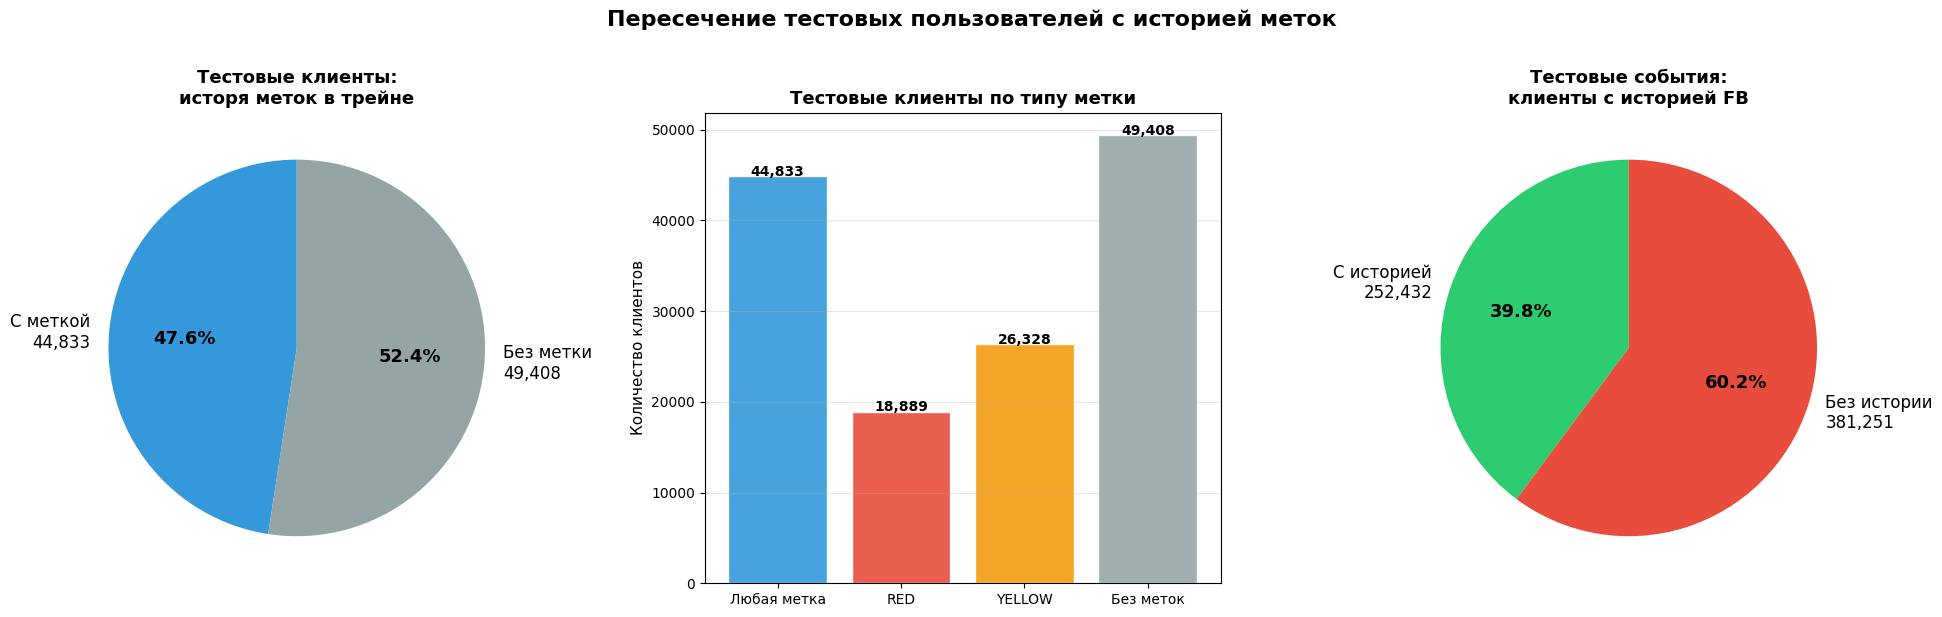


График сохранён: /kaggle/working/eda_plots/05_test_user_overlap.png


In [12]:
"""EDA #5: Сколько тестовых пользователей имеют историю меток в трейне."""

# - 1. Тестовые клиенты -
print("\nЗагрузка тестовых данных...")
test_df = pl.read_parquet(DATA_DIR / "test.parquet", columns=["customer_id", "event_id"])
test_customers = set(test_df["customer_id"].unique().to_list())
test_events = test_df.height
print(f"  Тестовых событий:    {test_events:,}")
print(f"  Уникальных клиентов: {len(test_customers):,}")

# - 2. Клиенты с метками в трейне -
print("\nЗагрузка меток и трейна...")
labels = pl.read_parquet(DATA_DIR / "train_labels.parquet")
labeled_event_ids = set(labels["event_id"].to_list())
red_event_ids = set(labels.filter(pl.col("target") == 1)["event_id"].to_list())
yellow_event_ids = set(labels.filter(pl.col("target") == 0)["event_id"].to_list())

# Собираем customer_id для размеченных событий
labeled_customers = set()
red_customers = set()
yellow_customers = set()

for i in [1, 2, 3]:
    print(f"  train_part_{i}...")
    df = pl.read_parquet(DATA_DIR / f"train_part_{i}.parquet",
                         columns=["event_id", "customer_id"])
    labeled_df = df.filter(pl.col("event_id").is_in(list(labeled_event_ids)))
    for row in labeled_df.iter_rows(named=True):
        eid = row["event_id"]
        cid = row["customer_id"]
        labeled_customers.add(cid)
        if eid in red_event_ids:
            red_customers.add(cid)
        if eid in yellow_event_ids:
            yellow_customers.add(cid)
    del df, labeled_df

print(f"\n  Клиентов с любой меткой:   {len(labeled_customers):,}")
print(f"  Клиентов с RED:            {len(red_customers):,}")
print(f"  Клиентов с YELLOW:         {len(yellow_customers):,}")

# - 3. Пересечение -
test_with_labels = test_customers & labeled_customers
test_with_red = test_customers & red_customers
test_with_yellow = test_customers & yellow_customers
test_no_labels = test_customers - labeled_customers

print(f"\n--- Пересечение ---")
print(f"  Тестовых клиентов с любой меткой:  {len(test_with_labels):>6,} ({100*len(test_with_labels)/len(test_customers):.1f}%)")
print(f"  Тестовых клиентов с RED:           {len(test_with_red):>6,} ({100*len(test_with_red)/len(test_customers):.1f}%)")
print(f"  Тестовых клиентов с YELLOW:        {len(test_with_yellow):>6,} ({100*len(test_with_yellow)/len(test_customers):.1f}%)")
print(f"  Тестовых клиентов БЕЗ меток:       {len(test_no_labels):>6,} ({100*len(test_no_labels)/len(test_customers):.1f}%)")

# - 4. Сколько тестовых событий приходится на клиентов с/без меток -
test_events_with_hist = test_df.filter(pl.col("customer_id").is_in(list(test_with_labels))).height
test_events_no_hist = test_df.filter(pl.col("customer_id").is_in(list(test_no_labels))).height
print(f"\n  Тестовых событий от клиентов с меткой:  {test_events_with_hist:>8,} ({100*test_events_with_hist/test_events:.1f}%)")
print(f"  Тестовых событий от клиентов без метки: {test_events_no_hist:>8,} ({100*test_events_no_hist/test_events:.1f}%)")

# - 5. Также: пересечение с претрейном (кол-во клиентов вообще) -
print("\nПроверка пересечения с претрейном...")
pretrain_customers = set()
for i in [1, 2, 3]:
    custs = pl.read_parquet(DATA_DIR / f"pretrain_part_{i}.parquet",
                            columns=["customer_id"])["customer_id"].unique().to_list()
    pretrain_customers.update(custs)
train_customers = set()
for i in [1, 2, 3]:
    custs = pl.read_parquet(DATA_DIR / f"train_part_{i}.parquet",
                            columns=["customer_id"])["customer_id"].unique().to_list()
    train_customers.update(custs)

test_in_pretrain = test_customers & pretrain_customers
test_in_train = test_customers & train_customers
print(f"  Тестовых клиентов в претрейне: {len(test_in_pretrain):,} ({100*len(test_in_pretrain)/len(test_customers):.1f}%)")
print(f"  Тестовых клиентов в трейне:    {len(test_in_train):,} ({100*len(test_in_train)/len(test_customers):.1f}%)")

# - 6. Визуализация -
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
sizes = [len(test_with_labels), len(test_no_labels)]
labels_pie = [f"С меткой\n{len(test_with_labels):,}", f"Без метки\n{len(test_no_labels):,}"]
colors = ["#3498db", "#95a5a6"]
wedges, texts, autotexts = ax.pie(sizes, labels=labels_pie, colors=colors,
                                   autopct="%1.1f%%", startangle=90,
                                   textprops={"fontsize": 12})
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(13)
ax.set_title("Тестовые клиенты:\nисторя меток в трейне", fontsize=13, fontweight="bold")

ax = axes[1]
categories = ["Любая метка", "RED", "YELLOW", "Без меток"]
counts = [len(test_with_labels), len(test_with_red), len(test_with_yellow), len(test_no_labels)]
colors_bar = ["#3498db", "#e74c3c", "#f39c12", "#95a5a6"]
bars = ax.bar(categories, counts, color=colors_bar, edgecolor="white", alpha=0.9)
ax.set_ylabel("Количество клиентов", fontsize=11)
ax.set_title("Тестовые клиенты по типу метки", fontsize=13, fontweight="bold")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{cnt:,}", ha="center", fontsize=10, fontweight="bold")
ax.grid(alpha=0.3, axis="y")

ax = axes[2]
sizes_ev = [test_events_with_hist, test_events_no_hist]
labels_ev = [f"С историей\n{test_events_with_hist:,}", f"Без истории\n{test_events_no_hist:,}"]
colors_ev = ["#2ecc71", "#e74c3c"]
wedges, texts, autotexts = ax.pie(sizes_ev, labels=labels_ev, colors=colors_ev,
                                   autopct="%1.1f%%", startangle=90,
                                   textprops={"fontsize": 12})
for at in autotexts:
    at.set_fontweight("bold")
    at.set_fontsize(13)
ax.set_title("Тестовые события:\nклиенты с историей FB", fontsize=13, fontweight="bold")

plt.suptitle("Пересечение тестовых пользователей с историей меток", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "05_test_user_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nГрафик сохранён: {OUT_DIR / '05_test_user_overlap.png'}")

del test_df